In [2]:
# ============================================================
# CELL 1 - Imports & Setup
# ============================================================
"""
SimCLR — A Simple Framework for Contrastive Learning of Visual Representations
Implementation from scratch, based on Chen et al. 2020 (arxiv.org/abs/2002.05709)

SNU Internship - Week 01
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import time
# Création des dossiers de travail
import os
os.makedirs('results', exist_ok=True)
os.makedirs('checkpoints', exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

torch.manual_seed(42)
np.random.seed(42)

Device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU


In [4]:
# ============================================================
# CELL 2 - SimCLR Augmentations (Section 4.1 du paper)
# ============================================================
"""
Le papier montre que la combinaison Random Crop + Color Distortion
est celle qui produit les meilleures représentations.
Chaque image produit DEUX vues augmentées indépendamment = la paire positive.
"""

class SimCLRAugmentation:
    """
    Génère deux vues augmentées de la même image.
    C'est le coeur de la méthode : pas de labels, juste deux vues
    de la même réalité visuelle que le modèle doit apprendre à rapprocher.
    """
    def __init__(self, image_size=32):
        # CIFAR-10 fait 32x32, on adapte les paramètres du paper en conséquence
        color_jitter = T.ColorJitter(
            brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1
        )

        self.transform = T.Compose([
            T.RandomResizedCrop(size=image_size, scale=(0.2, 1.0)),
            T.RandomHorizontalFlip(p=0.5),
            T.RandomApply([color_jitter], p=0.8),
            T.RandomGrayscale(p=0.2),
            T.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
            T.ToTensor(),
            T.Normalize(mean=[0.4914, 0.4822, 0.4465],
                        std=[0.2470, 0.2435, 0.2616]),
        ])

    def __call__(self, x):
        return self.transform(x), self.transform(x)


class SimCLRDataset(Dataset):
    """Wrapper qui applique l'augmentation double à chaque image du dataset."""
    def __init__(self, base_dataset, transform):
        self.base_dataset = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        img, label = self.base_dataset[idx]
        x_i, x_j = self.transform(img)
        return x_i, x_j, label

In [ ]:
# ============================================================
# CELL 3 - Chargement CIFAR-10
# ============================================================

raw_train = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True
)
raw_test = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True
)

simclr_aug = SimCLRAugmentation(image_size=32)
train_dataset = SimCLRDataset(raw_train, simclr_aug)

# Pour l'évaluation linéaire plus tard, on garde aussi une version "normale" (1 seule vue)
eval_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.4914, 0.4822, 0.4465],
                std=[0.2470, 0.2435, 0.2616]),
])

BATCH_SIZE = 256  # ajuste selon ta VRAM (HP Victus -> probablement 256 ou 512 ok)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=4, drop_last=True, pin_memory=True
)

print(f"Nombre de batchs par epoch: {len(train_loader)}")
print(f"Taille du dataset: {len(train_dataset)}")

# Visualisation rapide : vérifier que les augmentations ont du sens
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
x_i, x_j, _ = next(iter(train_loader))
for k in range(6):
    img_i = x_i[k].permute(1, 2, 0).numpy()
    img_j = x_j[k].permute(1, 2, 0).numpy()
    img_i = (img_i - img_i.min()) / (img_i.max() - img_i.min())
    img_j = (img_j - img_j.min()) / (img_j.max() - img_j.min())
    axes[0, k].imshow(img_i)
    axes[0, k].axis('off')
    axes[1, k].imshow(img_j)
    axes[1, k].axis('off')
axes[0, 0].set_ylabel("Vue 1", fontsize=12)
axes[1, 0].set_ylabel("Vue 2", fontsize=12)
plt.suptitle("Paires positives générées par les augmentations SimCLR", fontsize=14)
plt.tight_layout()
plt.savefig('results/augmentation_examples.png', dpi=150, bbox_inches='tight')
plt.show()

100.0%


Nombre de batchs par epoch: 195
Taille du dataset: 50000


Nombre de batchs par epoch: 195
Taille du dataset: 50000


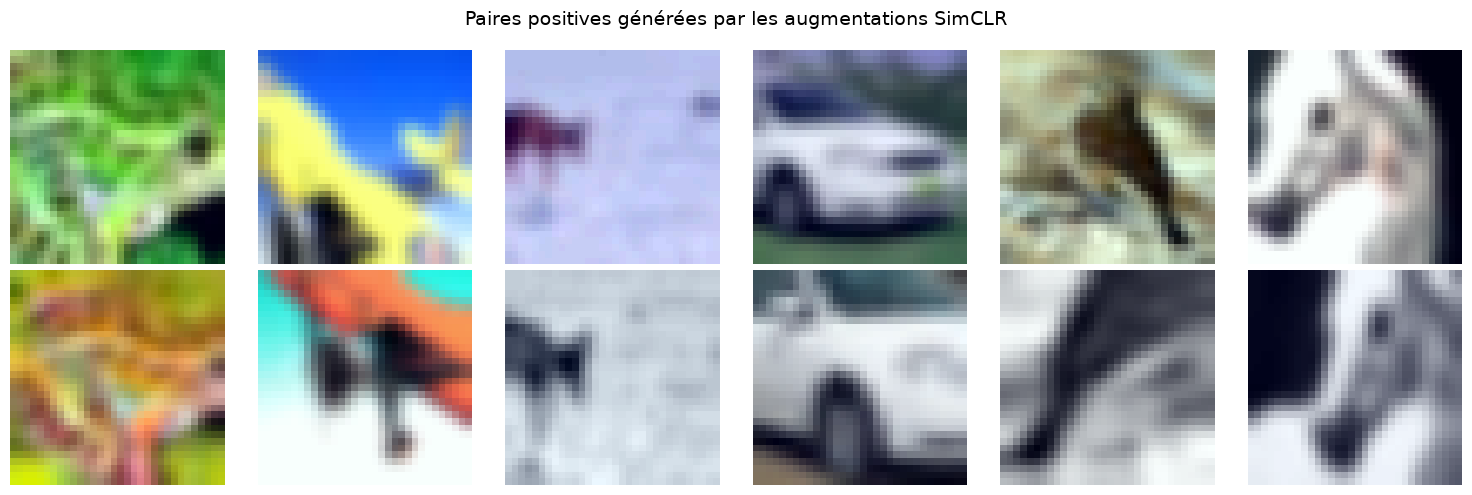

In [ ]:
# ============================================================
# CELL 3bis - Chargement CIFAR-10 (dowload = False)
# ============================================================

# Le fichier est déjà téléchargé, on désactive la vérification
raw_train = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=False  # <- False 
)
raw_test = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=False  # <- False 
)

simclr_aug = SimCLRAugmentation(image_size=32)
train_dataset = SimCLRDataset(raw_train, simclr_aug)

# Pour l'évaluation linéaire plus tard, on garde aussi une version "normale" (1 seule vue)
eval_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.4914, 0.4822, 0.4465],
                std=[0.2470, 0.2435, 0.2616]),
])

BATCH_SIZE = 256  # ajuste selon ta VRAM (HP Victus -> probablement 256 ou 512 ok)
# Remplace num_workers=4 par 0 pour le debug sur Windows
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0,  # <- 0 = pas de multiprocessing, plus lent mais stable sur Windows
    drop_last=True, pin_memory=True
)

print(f"Nombre de batchs par epoch: {len(train_loader)}")
print(f"Taille du dataset: {len(train_dataset)}")

# Visualisation rapide : vérifier que les augmentations ont du sens
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
x_i, x_j, _ = next(iter(train_loader))
for k in range(6):
    img_i = x_i[k].permute(1, 2, 0).numpy()
    img_j = x_j[k].permute(1, 2, 0).numpy()
    img_i = (img_i - img_i.min()) / (img_i.max() - img_i.min())
    img_j = (img_j - img_j.min()) / (img_j.max() - img_j.min())
    axes[0, k].imshow(img_i)
    axes[0, k].axis('off')
    axes[1, k].imshow(img_j)
    axes[1, k].axis('off')
axes[0, 0].set_ylabel("Vue 1", fontsize=12)
axes[1, 0].set_ylabel("Vue 2", fontsize=12)
plt.suptitle("Paires positives générées par les augmentations SimCLR", fontsize=14)
plt.tight_layout()
plt.savefig('results/augmentation_examples.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# ============================================================
# CELL 4 - Architecture : Encoder + Projection Head
# ============================================================
"""
Deux composants distincts (Figure 2 du paper) :

1. Encoder f(.) : un ResNet standard. C'est CE composant qu'on garde
   après l'entraînement -> ses sorties h sont les représentations utiles.

2. Projection head g(.) : un petit MLP qui projette h vers un espace z
   où la loss contrastive est calculée. Il est JETÉ après l'entraînement.

Pourquoi jeter g(.) ? Le paper montre empiriquement que la loss contrastive
détruit de l'information utile pour les tâches downstream (ex: couleur,
orientation) car elle pousse z à être invariant aux augmentations.
h, en amont du projection head, conserve plus d'information générale.
"""

def get_resnet18_cifar():
    """
    ResNet-18 adapté à CIFAR (images 32x32, contrairement à ImageNet 224x224).
    On remplace la première conv (7x7, stride 2) par une conv 3x3 stride 1,
    et on retire le maxpool initial — sinon l'image rétrécit trop vite
    pour des images aussi petites.
    """
    resnet = torchvision.models.resnet18(weights=None)
    resnet.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    resnet.maxpool = nn.Identity()
    resnet.fc = nn.Identity()  # on retire la tête de classification
    return resnet


class ProjectionHead(nn.Module):
    """MLP à 2 couches, comme spécifié Section 4.1 du paper."""
    def __init__(self, input_dim=512, hidden_dim=512, output_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)


class SimCLRModel(nn.Module):
    """
    Encoder + Projection head, avec retour des deux représentations
    (h pour l'eval future, z pour la loss).
    """
    def __init__(self, projection_dim=128):
        super().__init__()
        self.encoder = get_resnet18_cifar()
        self.projection_head = ProjectionHead(
            input_dim=512, hidden_dim=512, output_dim=projection_dim
        )

    def forward(self, x):
        h = self.encoder(x)            # représentation utile (512-d)
        z = self.projection_head(h)    # représentation pour la loss (128-d)
        z = F.normalize(z, dim=1)      # normalisation L2, nécessaire pour la similarité cosinus
        return h, z


model = SimCLRModel(projection_dim=128).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Nombre de paramètres: {n_params:,}")

Nombre de paramètres: 11,497,152


In [10]:
# ============================================================
# CELL 5 - NT-Xent Loss (Normalized Temperature-scaled Cross Entropy)
# ============================================================
"""
Section 3 du paper. C'est le coeur mathématique de SimCLR.

Pour un batch de N images -> 2N vues augmentées.
Pour la vue i, sa SEULE paire positive est l'autre vue de la même image.
Toutes les 2(N-1) autres vues du batch sont des négatifs.

loss(i,j) = -log [ exp(sim(z_i,z_j)/tau) / sum_k!=i exp(sim(z_i,z_k)/tau) ]

Implémentation vectorisée (pas de boucle Python -> rapide sur GPU).
"""

class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5, batch_size=256):
        super().__init__()
        self.temperature = temperature
        self.batch_size = batch_size
        # masque pour exclure la similarité d'un élément avec lui-même
        self.register_buffer(
            "negatives_mask",
            (~torch.eye(2 * batch_size, 2 * batch_size, dtype=bool))
        )

    def forward(self, z_i, z_j):
        batch_size = z_i.shape[0]
        # Si dernier batch incomplet, on adapte le masque dynamiquement
        if batch_size != self.batch_size:
            negatives_mask = (~torch.eye(2 * batch_size, 2 * batch_size,
                                          dtype=bool, device=z_i.device))
        else:
            negatives_mask = self.negatives_mask

        representations = torch.cat([z_i, z_j], dim=0)  # (2N, D)

        # Matrice de similarité cosinus complète (2N, 2N)
        similarity_matrix = F.cosine_similarity(
            representations.unsqueeze(1), representations.unsqueeze(0), dim=2
        )

        # Les positifs : (i, i+N) et (i+N, i)
        sim_ij = torch.diag(similarity_matrix, batch_size)
        sim_ji = torch.diag(similarity_matrix, -batch_size)
        positives = torch.cat([sim_ij, sim_ji], dim=0)

        nominator = torch.exp(positives / self.temperature)
        denominator = negatives_mask.to(z_i.device) * torch.exp(
            similarity_matrix / self.temperature
        )

        loss_partial = -torch.log(nominator / torch.sum(denominator, dim=1))
        loss = torch.sum(loss_partial) / (2 * batch_size)
        return loss


# Test rapide pour vérifier que la loss fonctionne et donne une valeur sensée
_test_loss_fn = NTXentLoss(temperature=0.5, batch_size=8)
_z_i = F.normalize(torch.randn(8, 128), dim=1)
_z_j = F.normalize(torch.randn(8, 128), dim=1)
print(f"Test loss (vecteurs random, doit être proche de log(2N-1)): {_test_loss_fn(_z_i, _z_j).item():.4f}")
print(f"log(2N-1) théorique pour comparaison: {np.log(2*8-1):.4f}")

Test loss (vecteurs random, doit être proche de log(2N-1)): 2.7007
log(2N-1) théorique pour comparaison: 2.7081


Début de l'entraînement : 20 epochs, batch size 256
Epoch [1/20] | Loss: 5.2701 | LR: 0.000298 | Time: 128.2s
Epoch [2/20] | Loss: 5.0375 | LR: 0.000293 | Time: 133.9s
Epoch [3/20] | Loss: 4.9599 | LR: 0.000284 | Time: 133.6s
Epoch [4/20] | Loss: 4.9098 | LR: 0.000271 | Time: 130.1s
Epoch [5/20] | Loss: 4.8742 | LR: 0.000256 | Time: 124.8s
Epoch [6/20] | Loss: 4.8471 | LR: 0.000238 | Time: 131.1s
Epoch [7/20] | Loss: 4.8293 | LR: 0.000218 | Time: 132.2s
Epoch [8/20] | Loss: 4.8113 | LR: 0.000196 | Time: 124.6s
Epoch [9/20] | Loss: 4.7921 | LR: 0.000173 | Time: 138.1s
Epoch [10/20] | Loss: 4.7782 | LR: 0.000150 | Time: 140.3s
Epoch [11/20] | Loss: 4.7683 | LR: 0.000127 | Time: 138.7s
Epoch [12/20] | Loss: 4.7559 | LR: 0.000104 | Time: 132.9s
Epoch [13/20] | Loss: 4.7482 | LR: 0.000082 | Time: 134.9s
Epoch [14/20] | Loss: 4.7399 | LR: 0.000062 | Time: 133.8s
Epoch [15/20] | Loss: 4.7295 | LR: 0.000044 | Time: 133.7s
Epoch [16/20] | Loss: 4.7247 | LR: 0.000029 | Time: 133.6s
Epoch [17/20]

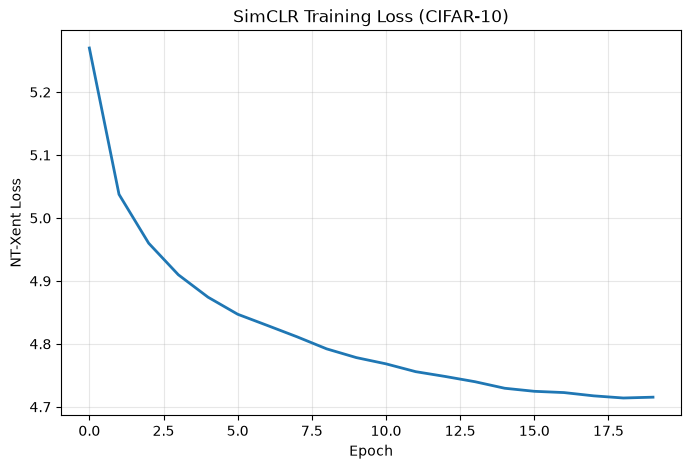

In [12]:
# ============================================================
# CELL 6 - Training Loop
# ============================================================
"""
Boucle d'entraînement standard. Points d'attention :
- LARS ou Adam : le paper original utilise LARS (pour très grands batchs),
  mais Adam fonctionne très bien à notre échelle (batch 256-512).
- On garde l'historique de loss pour le rapport.
- On sauvegarde des checkpoints pour pouvoir reprendre si besoin.
"""

NUM_EPOCHS = 20          # ajustable selon le temps disponible cette nuit
LEARNING_RATE = 3e-4
TEMPERATURE = 0.5
WEIGHT_DECAY = 1e-6
BATCH_SIZE = 256

model = SimCLRModel(projection_dim=128).to(device)
criterion = NTXentLoss(temperature=TEMPERATURE, batch_size=BATCH_SIZE).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

loss_history = []
os.makedirs('checkpoints', exist_ok=True)

print(f"Début de l'entraînement : {NUM_EPOCHS} epochs, batch size {BATCH_SIZE}")
start_time = time.time()

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0.0
    epoch_start = time.time()

    for batch_idx, (x_i, x_j, _) in enumerate(train_loader):
        x_i, x_j = x_i.to(device, non_blocking=True), x_j.to(device, non_blocking=True)

        optimizer.zero_grad()
        _, z_i = model(x_i)
        _, z_j = model(x_j)
        loss = criterion(z_i, z_j)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    epoch_time = time.time() - epoch_start

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | Loss: {avg_loss:.4f} | "
          f"LR: {scheduler.get_last_lr()[0]:.6f} | Time: {epoch_time:.1f}s")

    # Checkpoint régulier (utile si la nuit s'arrête plus tôt que prévu)
    if (epoch + 1) % 10 == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss_history': loss_history,
        }, f'checkpoints/simclr_epoch{epoch+1}.pt')

total_time = time.time() - start_time
print(f"\nEntraînement terminé en {total_time/60:.1f} minutes")

torch.save(model.state_dict(), 'checkpoints/simclr_final.pt')

# Courbe de loss -- premier visuel pour le rapport
plt.figure(figsize=(8, 5))
plt.plot(loss_history, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('NT-Xent Loss')
plt.title('SimCLR Training Loss (CIFAR-10)')
plt.grid(alpha=0.3)
plt.savefig('results/training_curve.png', dpi=150, bbox_inches='tight')
plt.show()


In [8]:
# ============================================================
# CELL 7 - Évaluation : Linear Probing
# ============================================================
"""
LA métrique de référence du paper (Table 6).
Principe : on gèle l'encoder entraîné, on extrait les représentations h,
et on entraîne UNE SEULE régression logistique linéaire dessus avec les
vrais labels CIFAR-10.

Si les représentations apprises sans labels sont bonnes, une simple
frontière linéaire suffit à bien classifier -> c'est la preuve que
l'information utile est "facilement accessible" dans l'espace appris.
"""

@torch.no_grad()
def extract_features(model, dataset, device, batch_size=512):
    model.eval()
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,   # <- 0 résout le problème Windows
        pin_memory=False # <- désactivé aussi pour éviter les conflits
    )
    features, labels = [], []
    for imgs, lbls in loader:
        imgs = imgs.to(device)
        h, _ = model(imgs)
        features.append(h.cpu().numpy())
        labels.append(lbls.numpy())
    return np.concatenate(features), np.concatenate(labels)


class EvalDataset(Dataset):
    """Dataset simple à une seule vue, pour l'extraction de features."""
    def __init__(self, base_dataset, transform):
        self.base_dataset = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        img, label = self.base_dataset[idx]
        return self.transform(img), label


eval_train_dataset = EvalDataset(raw_train, eval_transform)
eval_test_dataset = EvalDataset(raw_test, eval_transform)

print("Extraction des features (train)...")
train_features, train_labels = extract_features(model, eval_train_dataset, device)
print("Extraction des features (test)...")
test_features, test_labels = extract_features(model, eval_test_dataset, device)

print(f"Shape features train: {train_features.shape}")

print("Entraînement de la régression logistique (linear probe)...")
clf = LogisticRegression(max_iter=1000, n_jobs=-1)
clf.fit(train_features, train_labels)

train_acc = accuracy_score(train_labels, clf.predict(train_features))
test_acc = accuracy_score(test_labels, clf.predict(test_features))

print(f"\n{'='*50}")
print(f"LINEAR PROBING RESULTS")
print(f"{'='*50}")
print(f"Train accuracy: {train_acc*100:.2f}%")
print(f"Test accuracy:  {test_acc*100:.2f}%")
print(f"(Baseline aléatoire pour 10 classes: 10.00%)")
print(f"{'='*50}")

# Sauvegarde des résultats pour le rapport
with open('results/linear_probe_results.txt', 'w') as f:
    f.write(f"Linear Probing Results - SimCLR on CIFAR-10\n")
    f.write(f"Train accuracy: {train_acc*100:.2f}%\n")
    f.write(f"Test accuracy: {test_acc*100:.2f}%\n")
    f.write(f"Random baseline: 10.00%\n")


Extraction des features (train)...
Extraction des features (test)...
Shape features train: (50000, 512)
Entraînement de la régression logistique (linear probe)...


c:\Users\romai\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



LINEAR PROBING RESULTS
Train accuracy: 45.47%
Test accuracy:  42.26%
(Baseline aléatoire pour 10 classes: 10.00%)


c:\Users\romai\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Calcul du t-SNE (peut prendre 1-2 minutes)...


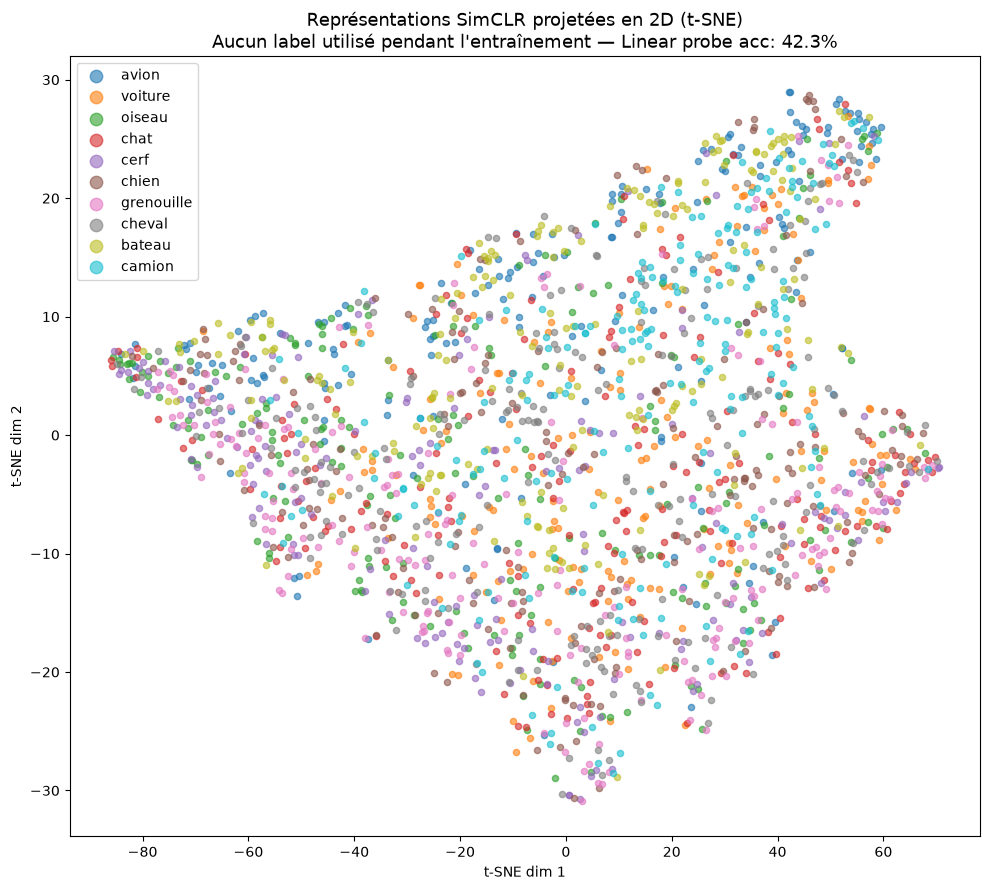


Interprétation pour le rapport :
Si les clusters de couleurs sont visuellement séparés, cela démontre
que SimCLR a appris une structure sémantique des images uniquement
via les relations entre vues augmentées — aucun label n'a été utilisé.


In [9]:
# ============================================================
# CELL 8 - Visualisation t-SNE
# ============================================================
"""
La meilleure preuve visuelle que le modèle a appris quelque chose de
sémantiquement pertinent SANS AVOIR JAMAIS VU UN LABEL : projeter les
représentations en 2D et observer si les classes se regroupent naturellement.
"""

CIFAR10_CLASSES = ['avion', 'voiture', 'oiseau', 'chat', 'cerf',
                    'chien', 'grenouille', 'cheval', 'bateau', 'camion']

# On utilise un sous-échantillon du test set pour que le t-SNE soit rapide et lisible
N_SAMPLES = 2000
idx = np.random.choice(len(test_features), N_SAMPLES, replace=False)
sub_features = test_features[idx]
sub_labels = test_labels[idx]

print("Calcul du t-SNE (peut prendre 1-2 minutes)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
features_2d = tsne.fit_transform(sub_features)

plt.figure(figsize=(10, 9))
colors = plt.cm.tab10(np.linspace(0, 1, 10))
for class_idx in range(10):
    mask = sub_labels == class_idx
    plt.scatter(features_2d[mask, 0], features_2d[mask, 1],
                c=[colors[class_idx]], label=CIFAR10_CLASSES[class_idx],
                alpha=0.6, s=20)

plt.legend(loc='best', fontsize=10, markerscale=2)
plt.title('Représentations SimCLR projetées en 2D (t-SNE)\n'
          f'Aucun label utilisé pendant l\'entraînement — Linear probe acc: {test_acc*100:.1f}%',
          fontsize=13)
plt.xlabel('t-SNE dim 1')
plt.ylabel('t-SNE dim 2')
plt.tight_layout()
plt.savefig('results/tsne_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInterprétation pour le rapport :")
print("Si les clusters de couleurs sont visuellement séparés, cela démontre")
print("que SimCLR a appris une structure sémantique des images uniquement")
print("via les relations entre vues augmentées — aucun label n'a été utilisé.")


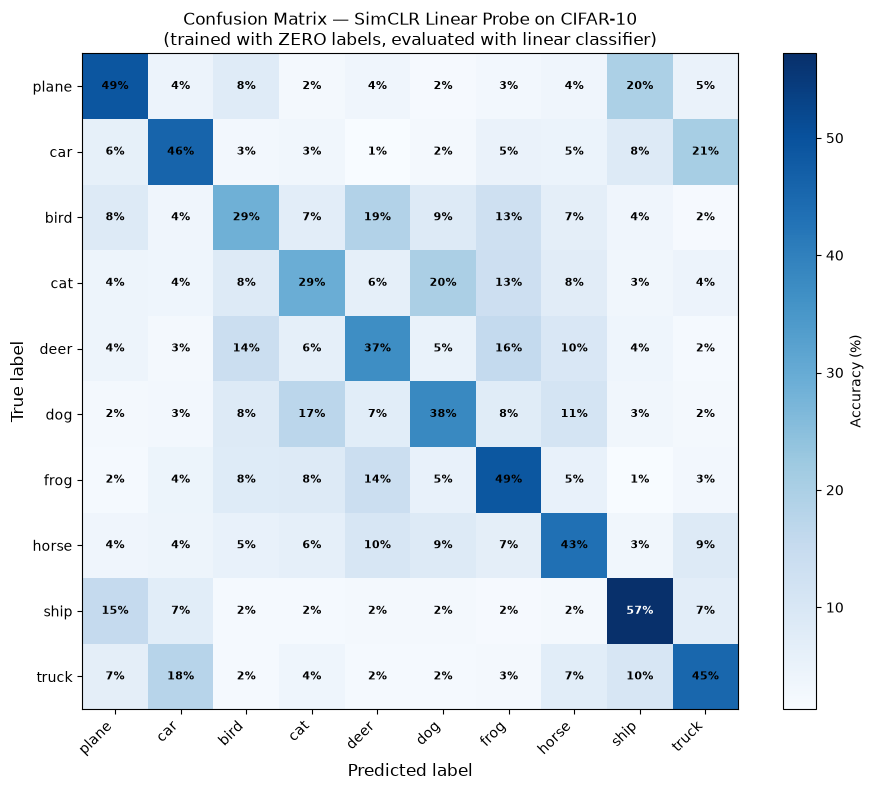


Classes les plus difficiles :
  bird     : 28.6% correctement classifié
  cat      : 29.4% correctement classifié
  deer     : 37.1% correctement classifié
  dog      : 38.0% correctement classifié
  horse    : 43.3% correctement classifié
  truck    : 45.4% correctement classifié
  car      : 45.9% correctement classifié
  frog     : 48.7% correctement classifié
  plane    : 49.0% correctement classifié
  ship     : 57.2% correctement classifié


In [10]:
# ============================================================
# CELLULE A — Matrice de confusion
# ============================================================
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

CIFAR10_CLASSES = ['plane', 'car', 'bird', 'cat', 'deer',
                    'dog', 'frog', 'horse', 'ship', 'truck']

y_pred = clf.predict(test_features)
cm = confusion_matrix(test_labels, y_pred)

# Normalisation par ligne (en %)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm_norm, cmap='Blues')
plt.colorbar(im, ax=ax, label='Accuracy (%)')

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha='right')
ax.set_yticklabels(CIFAR10_CLASSES)

for i in range(10):
    for j in range(10):
        color = 'white' if cm_norm[i, j] > 50 else 'black'
        ax.text(j, i, f'{cm_norm[i,j]:.0f}%', ha='center', va='center',
                fontsize=8, color=color, fontweight='bold')

ax.set_xlabel('Predicted label', fontsize=12)
ax.set_ylabel('True label', fontsize=12)
ax.set_title('Confusion Matrix — SimCLR Linear Probe on CIFAR-10\n'
             '(trained with ZERO labels, evaluated with linear classifier)', fontsize=12)
plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Quelles classes sont les plus confondues ?
print("\nClasses les plus difficiles :")
diag = np.diag(cm_norm)
for idx in np.argsort(diag):
    print(f"  {CIFAR10_CLASSES[idx]:8s} : {diag[idx]:.1f}% correctement classifié")


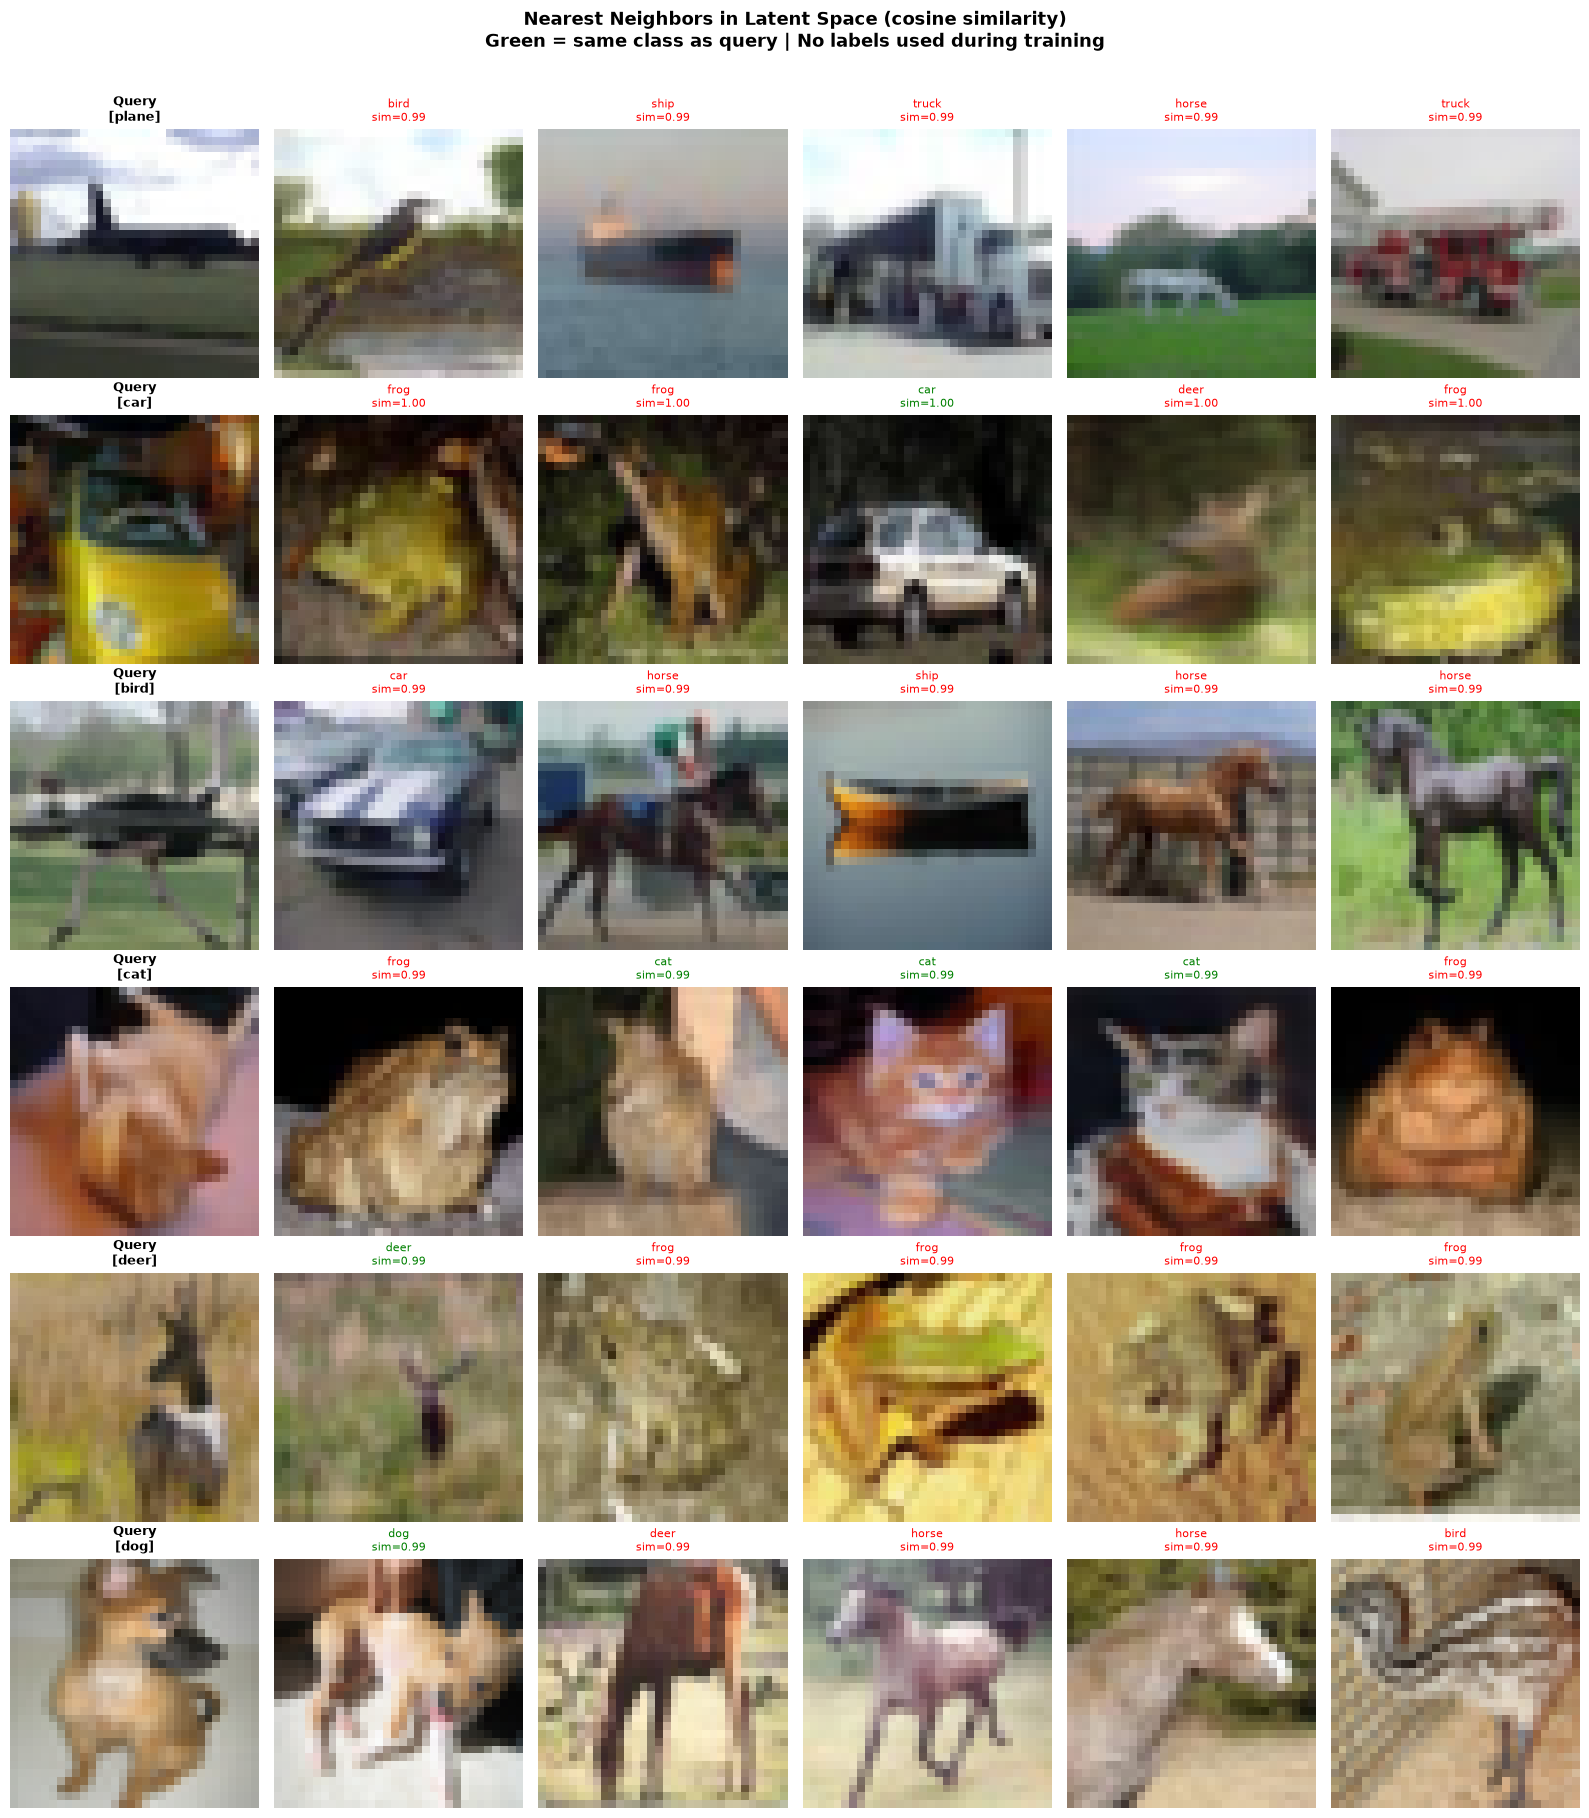

In [11]:
# ============================================================
# CELLULE B — Nearest Neighbors dans l'espace latent
# ============================================================
"""
C'est la visualisation la plus intuitive et convaincante.
Aucun label utilisé pour trouver ces voisins : uniquement la
similarité cosinus entre représentations apprises.
"""
from sklearn.metrics.pairwise import cosine_similarity

# Normalisation des features pour similarité cosinus
test_feat_norm = test_features / (np.linalg.norm(test_features, axis=1, keepdims=True) + 1e-8)
sim_matrix = cosine_similarity(test_feat_norm)

# On prend 6 images query au hasard (une par classe si possible)
N_QUERIES = 6
N_NEIGHBORS = 5

# Sélection d'une image par classe pour les queries
query_indices = []
for class_idx in range(N_QUERIES):
    candidates = np.where(test_labels == class_idx)[0]
    query_indices.append(np.random.choice(candidates))

# Récupérer les images brutes du test set
raw_test_images = []
for i in range(len(raw_test)):
    img, _ = raw_test[i]
    raw_test_images.append(np.array(img))
raw_test_images = np.array(raw_test_images)

fig, axes = plt.subplots(N_QUERIES, N_NEIGHBORS + 1, figsize=(16, 3 * N_QUERIES))

for row, q_idx in enumerate(query_indices):
    # Similarités avec toutes les autres images
    sims = sim_matrix[q_idx].copy()
    sims[q_idx] = -1  # exclure l'image elle-même
    nn_indices = np.argsort(sims)[::-1][:N_NEIGHBORS]

    # Image query
    axes[row, 0].imshow(raw_test_images[q_idx])
    true_class = CIFAR10_CLASSES[test_labels[q_idx]]
    axes[row, 0].set_title(f'Query\n[{true_class}]', fontsize=9, fontweight='bold')
    axes[row, 0].axis('off')
    axes[row, 0].patch.set_edgecolor('gold')
    axes[row, 0].patch.set_linewidth(3)

    # Voisins
    for col, nn_idx in enumerate(nn_indices):
        axes[row, col + 1].imshow(raw_test_images[nn_idx])
        nn_class = CIFAR10_CLASSES[test_labels[nn_idx]]
        sim_score = sim_matrix[q_idx, nn_idx]
        color = 'green' if test_labels[nn_idx] == test_labels[q_idx] else 'red'
        axes[row, col + 1].set_title(f'{nn_class}\nsim={sim_score:.2f}',
                                      fontsize=8, color=color)
        axes[row, col + 1].axis('off')

plt.suptitle('Nearest Neighbors in Latent Space (cosine similarity)\n'
             'Green = same class as query | No labels used during training',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('results/nearest_neighbors.png', dpi=150, bbox_inches='tight')
plt.show()
